# 07 - Advanced Credit Risk Model Development.

## Objective

This notebook develops and benchmarks nonlinear machine-learning models against the Logistic Regression benchmark established in the previous modeling stage.

This objective is to determine whether more flexible models can improve default-risk discrimination while maintaining a rigorous, reproducible, and leakage-free evaluation framework.

### Modeling Strategy

The modeling workflow follows a challenger-model framework:

1. Establish Logistic Regression as the interpretable benchmark.
2. Evaluate a feature-engineered Logistic Regression specification. 
3. Develop nonlinear tree-based challenger models.
4. Compare models using consistent out-of-sample metrics.
5. Identify the strongest candidate for subsequent hyperparameter optimization and decision-threshold analysis.

### Evaluation Principles

Because the application dataset exhibits substantial class imbalance, model performance will not be evaluated using accuracy alone.

The primary discrimination metrics are:

- **ROC-AUC** - overall ranking/discrimination ability
- **PR-AUC** - precision-recall performance, particularly informative under class imbalance.

Threshold-dependent metrics such as precision, recall, and F1-score will be considered separately because they depend on selected classification threshold.

The test set will remain untouched during model development and selection. It will be used only for final out-of-sample comparison.

In [1]:
# Importing the required libraries.
# Core libraries
from pathlib import Path
import pandas as pd
import numpy as np


# Visualization
import matplotlib.pyplot as plt

# Scikit-learn: data splitting
from sklearn.model_selection import train_test_split

# Scikit-learn: preprocessing and pipelines
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Scikit-learn: models
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                              HistGradientBoostingClassifier)

# Scikit-learn: evaluation
from sklearn.metrics import (roc_auc_score,
                             roc_curve,
                             average_precision_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             precision_recall_curve,
                             brier_score_loss,
                             confusion_matrix,
                             classification_report)

# Scikit-learn: calibration
from sklearn.calibration import calibration_curve

# Scikit-learn: inspection
from sklearn.inspection import (permutation_importance,
                                PartialDependenceDisplay)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print(f"Random state: {RANDOM_STATE}")

Libraries imported successfully.
Random state: 42


## Modeling Dataset

The modeling dataset is reconstructed from the structurally cleaned application dataset used in the preceding stages.

The six engineered predictors developed in Notebook 06 are recreated using the same definitions. This makes Notebook 07 independently reproducible while preserving consistency with the previous feature-engineering stage.

The original train/test split is reproduced using the same stratified 80/20 split and random seed.

In [2]:
# Loading the structurally cleaned dataset.
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (PROJECT_ROOT/ "data"/ "application_train_structural_cleaned.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at:\n{DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
print("Target Present:", "TARGET" in df.columns)
print("Data Path:", DATA_PATH.resolve())

df.head()

Dataset Shape: (307511, 105)
Target Present: True
Data Path: C:\Users\unive\Desktop\Credit Risk Project\data\application_train_structural_cleaned.csv


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Recreating the six engineered features.
engineered_features = pd.DataFrame(index=df.index)

# 1. Credit-to-Income Ratio
engineered_features["CREDIT_INCOME_RATIO"] = (df["AMT_CREDIT"] /
                                              df["AMT_INCOME_TOTAL"].replace(0, np.nan))

# 2. Annuity-to-Income Ratio
engineered_features["ANNUITY_INCOME_RATIO"] = (df["AMT_ANNUITY"] /
                                               df["AMT_INCOME_TOTAL"].replace(0, np.nan))

# 3. Loan-to-Goods-Price Ratio
engineered_features["LOAN_GOODS_RATIO"] = (df["AMT_CREDIT"] /
                                           df["AMT_GOODS_PRICE"].replace(0, np.nan))

# 4. Applicant Age
engineered_features["AGE_YEARS"] = (df["DAYS_BIRTH"].abs() / 365.25)

# 5. Employment Anomaly
engineered_features["EMPLOYMENT_ANOMALY"] = (df["DAYS_EMPLOYED"] == 365243).astype(int)

# 6. Employment Duration
days_employed_clean = df["DAYS_EMPLOYED"].replace(365243, np.nan)

engineered_features["EMPLOYMENT_YEARS"] = (days_employed_clean.abs() / 365.25)

engineered_features_names = ["CREDIT_INCOME_RATIO", 
                            "ANNUITY_INCOME_RATIO",
                            "LOAN_GOODS_RATIO",
                            "AGE_YEARS",
                            "EMPLOYMENT_YEARS",
                            "EMPLOYMENT_ANOMALY"]

print("Engineered features created:", len(engineered_features_names))
print(engineered_features[engineered_features_names].describe().T)

Engineered features created: 6
                         count       mean        std        min        25%  \
CREDIT_INCOME_RATIO   307511.0   3.957570   2.689728   0.004808   2.018667   
ANNUITY_INCOME_RATIO  307499.0   0.180930   0.094574   0.000224   0.114782   
LOAN_GOODS_RATIO      307233.0   1.122995   0.124045   0.150000   1.000000   
AGE_YEARS             307511.0  43.906900  11.947950  20.503765  33.984942   
EMPLOYMENT_YEARS      252137.0   6.527500   6.402081   0.000000   2.099932   
EMPLOYMENT_ANOMALY    307511.0   0.180072   0.384248   0.000000   0.000000   

                            50%        75%        max  
CREDIT_INCOME_RATIO    3.265067   5.159880  84.736842  
ANNUITY_INCOME_RATIO   0.162833   0.229067   1.875965  
LOAN_GOODS_RATIO       1.118800   1.198000   6.000000  
AGE_YEARS             43.121150  53.886379  69.073238  
EMPLOYMENT_YEARS       4.511978   8.692676  49.040383  
EMPLOYMENT_ANOMALY     0.000000   0.000000   1.000000  


In [4]:
# Separate predictors and target.
X_original = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

# Adding engineered predictors to the original feature set.
X_engineered = pd.concat(
    [X_original,
     engineered_features[engineered_features_names]], axis=1)

print("Original feature count:", X_original.shape[1])
print("Engineered feature count:", X_engineered.shape[1])
print("Additional engineered features:", len(engineered_features_names))

Original feature count: 103
Engineered feature count: 109
Additional engineered features: 6


In [5]:
# Train / validation / test split

# Step 1: Reproduce the fixed stratified 80/20 holdout split.
X_engineered_train, X_engineered_test, y_engineered_train, y_engineered_test = (train_test_split(X_engineered,
                                                                                                 y,
                                                                                                 test_size=0.20,
                                                                                                 random_state=RANDOM_STATE,
                                                                                                 stratify=y))

# Step 2: Split the training portion into development-train and validation samples for model selection and tuning.
X_dev_train, X_valid, y_dev_train, y_valid = (train_test_split(X_engineered_train,
                                                               y_engineered_train,
                                                               test_size=0.20,
                                                               random_state=RANDOM_STATE,
                                                               stratify=y_engineered_train))

# Original-feature split retained for structural consistency.
X_original_train, X_original_test, y_original_train, y_original_test = (train_test_split(X_original,
                                                                                         y,
                                                                                         test_size=0.20,
                                                                                         random_state=RANDOM_STATE,
                                                                                         stratify=y))

print("Original training shape:", X_original_train.shape)
print("Original testing shape:", X_original_test.shape)

print("\nEngineered training shape:", X_engineered_train.shape)
print("Engineered testing shape:", X_engineered_test.shape)

print("\nDevelopment-train shape:", X_dev_train.shape)
print("Validation shape:", X_valid.shape)

print("\nTraining indices identical:",
      X_original_train.index.equals(X_engineered_train.index))

print("Testing indices identical:",
      X_original_test.index.equals(X_engineered_test.index))

print("\nTraining default rate:", y_engineered_train.mean())
print("Validation default rate:", y_valid.mean())
print("Test default rate:", y_engineered_test.mean())

Original training shape: (246008, 103)
Original testing shape: (61503, 103)

Engineered training shape: (246008, 109)
Engineered testing shape: (61503, 109)

Development-train shape: (196806, 109)
Validation shape: (49202, 109)

Training indices identical: True
Testing indices identical: True

Training default rate: 0.08072908198107379
Validation default rate: 0.0807284256737531
Test default rate: 0.08072776937710356


In [6]:
# Development / validation / test integrity checks
assert X_dev_train.index.intersection(X_valid.index).empty
assert X_dev_train.index.intersection(X_engineered_test.index).empty
assert X_valid.index.intersection(X_engineered_test.index).empty

assert y_dev_train.index.equals(X_dev_train.index)
assert y_valid.index.equals(X_valid.index)
assert y_engineered_test.index.equals(X_engineered_test.index)

print("Development, validation and test sets are mutually exclusive.")
print("Index integrity checks passed.")

Development, validation and test sets are mutually exclusive.
Index integrity checks passed.


## Evaluation Framework

Before model development, the modeling data are validated to ensure that:

- the train/test split is unchanged;
- the engineered feature set contains the expected six additional predictors;
- train and test contain identical feature columns;
- the target prevalence remains stable across the split.

These checks provide a reproducible foundation for comparing all subsequent models on the same holdout sample.

In [7]:
# Data integrity checks
assert X_engineered_train.shape == (246008, 109)
assert X_engineered_test.shape == (61503, 109)

assert X_engineered_train.columns.equals(X_engineered_test.columns)

assert X_original_train.index.equals(X_engineered_train.index)
assert X_original_test.index.equals(X_engineered_test.index)

assert y_engineered_train.index.equals(X_engineered_train.index)
assert y_engineered_test.index.equals(X_engineered_test.index)

assert set(engineered_features_names).issubset(X_engineered_train.columns)

print("All data integrity checks passed.")
print(f"Training observations: {len(X_engineered_train):,}")
print(f"Testing observations:  {len(X_engineered_test):,}")
print(f"Training features:     {X_engineered_train.shape[1]}")
print(f"Testing features:      {X_engineered_test.shape[1]}")

All data integrity checks passed.
Training observations: 246,008
Testing observations:  61,503
Training features:     109
Testing features:      109


In [8]:
# Building the feature-engineered preprocessor.

## Identify numerical and categorical predictors.

numeric_features_engineered = (X_engineered_train
                               .select_dtypes(include=["int64", "float64"])
                               .columns
                               .tolist())

categorical_features_engineered = (X_engineered_train
                                   .select_dtypes(include=["object", "string", "category", "bool"])
                                   .columns
                                   .tolist())

print("Numerical features:", len(numeric_features_engineered))
print("Categorical features:", len(categorical_features_engineered))

## Numerical preprocessing
numeric_pipeline_engineered = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
                                              ("scaler", StandardScaler())])

## Categorical preprocessing
categorical_pipeline_engineered = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                                  ("onehot", OneHotEncoder(handle_unknown="ignore"))])

## Combined preprocessing pipeline
preprocessor_engineered = ColumnTransformer(transformers=[("numeric",
                                                           numeric_pipeline_engineered,
                                                           numeric_features_engineered),
                                                           ("categorical",
                                                            categorical_pipeline_engineered,
                                                            categorical_features_engineered)])

print("Feature-engineered preprocessing pipeline created.")

Numerical features: 94
Categorical features: 15
Feature-engineered preprocessing pipeline created.


In [9]:
# Independent model pipeline factories
def build_logistic_pipeline():
    return Pipeline(steps=[("preprocessor", clone(preprocessor_engineered)),
                           ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])

def build_random_forest_pipeline():
    return Pipeline(steps=[("preprocessor", clone(preprocessor_engineered)),
                           ("model", RandomForestClassifier(n_estimators=150,
                                                            max_depth=12,
                                                            min_samples_leaf=20,
                                                            class_weight="balanced_subsample",
                                                            random_state=RANDOM_STATE,
                                                            n_jobs=-1))])

def build_gb_pipeline(max_iter,
                      learning_rate,
                      max_leaf_nodes,
                      min_samples_leaf,
                      l2_regularization):
        return Pipeline(steps=[("preprocessor", clone(preprocessor_gb)),
                               ("model", HistGradientBoostingClassifier(max_iter=max_iter,
                                                                        learning_rate=learning_rate,
                                                                        max_leaf_nodes=max_leaf_nodes,
                                                                        min_samples_leaf=min_samples_leaf,
                                                                        l2_regularization=l2_regularization,
                                                                        random_state=RANDOM_STATE))])

print("Independent model pipeline factories created successfully.")

Independent model pipeline factories created successfully.


## Feature-Engineered Logistic Regression Benchmark

Logistic Regression is retained as the primary interpretable benchmark.

The model estimates the probability of default using the original predictors together with the six engineered credit-risk features developed in Notebook 06.

The model is trained using the same preprocessing pipeline established for the dataset:

- median imputation and standardisation for numerical variables;
- most-frequent imputation and one-hot encoding for categorical variables.

This benchmark provides the reference point against which nonlinear challenger models will subsequently be evaluated.

In [10]:
# Logistic Regression — validation benchmark
logistic_benchmark = build_logistic_pipeline()

logistic_benchmark.fit(X_dev_train,
y_dev_train)

y_prob_logistic_valid = logistic_benchmark.predict_proba(X_valid)[:, 1]

logistic_valid_metrics = {"ROC-AUC": roc_auc_score(y_valid, y_prob_logistic_valid),
                          "PR-AUC": average_precision_score(y_valid, y_prob_logistic_valid),
                          "Brier Score": brier_score_loss(y_valid, y_prob_logistic_valid)}

print("Validation Logistic Regression")
print("-" * 40)

for metric, value in logistic_valid_metrics.items():
    print(f"{metric}: {value:.4f}")

Validation Logistic Regression
----------------------------------------
ROC-AUC: 0.7447
PR-AUC: 0.2184
Brier Score: 0.0689


In [11]:
# Model evaluation helper
def evaluate_model(model,
                   X_eval,
                   y_eval,
                   model_name,
                   threshold=0.50):
   
    # Predicted probability of default
    y_prob = model.predict_proba(X_eval)[:, 1]

    # Convert probabilities into class predictions
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {"Model": model_name,
               "ROC-AUC": roc_auc_score(y_eval, y_prob),
               "PR-AUC": average_precision_score(y_eval,y_prob),
               "Precision": precision_score(y_eval, y_pred, zero_division=0),
               "Recall": recall_score(y_eval, y_pred, zero_division=0),
               "F1 Score": f1_score(y_eval, y_pred, zero_division=0)}

    return metrics, y_prob, y_pred

In [12]:
# Logistic Regression — validation evaluation
logistic_metrics, y_prob_logistic_valid, y_pred_logistic = evaluate_model(logistic_benchmark,
                                                                          X_valid,
                                                                          y_valid,
                                                                          model_name="Feature-Engineered Logistic Regression")

print(logistic_metrics)

{'Model': 'Feature-Engineered Logistic Regression', 'ROC-AUC': 0.7447489379002565, 'PR-AUC': 0.21844686444845798, 'Precision': 0.4830508474576271, 'Recall': 0.014350453172205438, 'F1 Score': 0.02787286063569682}


In [13]:
print(f"ROC-AUC:   {logistic_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC:    {logistic_metrics['PR-AUC']:.4f}")
print(f"Precision: {logistic_metrics['Precision']:.4f}")
print(f"Recall:    {logistic_metrics['Recall']:.4f}")
print(f"F1 Score:  {logistic_metrics['F1 Score']:.4f}")

ROC-AUC:   0.7447
PR-AUC:    0.2184
Precision: 0.4831
Recall:    0.0144
F1 Score:  0.0279


## Random Forest Challenger

Random Forest is introduced as the first nonlinear challenger to the Logistic Regression benchmark.

Unlike Logistic Regression, which imposes a linear relationship between predictors and the log-odds of default, Random Forest can capture:

- nonlinear predictor-response relationships;
- interaction effects between variables;
- threshold effects without requiring them to be manually specified.

Because the target is substantially imbalanced, class-balanced bootstrap sampling is incorporated through `class_weight="balanced_subsample"`.

The model will be evaluated on the same untouched test set used for the Logistic Regression benchmark.

In [14]:
# Random Forest — validation benchmark
random_forest_benchmark = build_random_forest_pipeline()

random_forest_benchmark.fit(X_dev_train,
                            y_dev_train)

y_prob_rf_valid = (random_forest_benchmark
                   .predict_proba(X_valid)[:, 1])

rf_valid_metrics = {"ROC-AUC": roc_auc_score(y_valid, y_prob_rf_valid),
                    "PR-AUC": average_precision_score(y_valid, y_prob_rf_valid),
                    "Brier Score": brier_score_loss(y_valid, y_prob_rf_valid)}

print("Validation Random Forest")
print("-" * 40)

for metric, value in rf_valid_metrics.items():
    print(f"{metric}: {value:.4f}")

Validation Random Forest
----------------------------------------
ROC-AUC: 0.7306
PR-AUC: 0.2022
Brier Score: 0.1828


In [15]:
# Random Forest probability diagnostic
print("Random Forest probability summary:")
print(pd.Series(y_prob_rf_valid).describe())

print("\nProbability range:")
print("Min:", y_prob_rf_valid.min())
print("Max:", y_prob_rf_valid.max())

print("\nObserved validation default rate:")
print(y_valid.mean())

print("\nRandom Forest Brier Score:")
print(brier_score_loss(y_valid, y_prob_rf_valid))

print("\nRandom Forest predicted probabilities — first 20:")

print(y_prob_rf_valid[:20])

Random Forest probability summary:
count    49202.000000
mean         0.408154
std          0.136491
min          0.075228
25%          0.301043
50%          0.394044
75%          0.504593
max          0.818820
dtype: float64

Probability range:
Min: 0.07522793740657677
Max: 0.8188197877929372

Observed validation default rate:
0.0807284256737531

Random Forest Brier Score:
0.18277091549563185

Random Forest predicted probabilities — first 20:
[0.50706719 0.21948708 0.19259831 0.3164368  0.58484638 0.40828204
 0.36311292 0.49625293 0.36263312 0.50571321 0.21064281 0.21395311
 0.72705353 0.44119865 0.46905517 0.49317721 0.32898616 0.46624962
 0.19642737 0.39742491]


In [16]:
# Random Forest — validation evaluation
rf_metrics, y_prob_rf, y_pred_rf = evaluate_model(random_forest_benchmark,
                                                  X_valid,
                                                  y_valid,
                                                  model_name="Random Forest")

print(rf_metrics)

{'Model': 'Random Forest', 'ROC-AUC': 0.7305874818177832, 'PR-AUC': 0.20216351163076438, 'Precision': 0.17336999214454046, 'Recall': 0.5556394763343404, 'F1 Score': 0.2642797269788049}


In [17]:
print(f"ROC-AUC:   {rf_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC:    {rf_metrics['PR-AUC']:.4f}")
print(f"Precision: {rf_metrics['Precision']:.4f}")
print(f"Recall:    {rf_metrics['Recall']:.4f}")
print(f"F1 Score:  {rf_metrics['F1 Score']:.4f}")

ROC-AUC:   0.7306
PR-AUC:    0.2022
Precision: 0.1734
Recall:    0.5556
F1 Score:  0.2643


In [18]:
# Initial model comparison
benchmark_results = pd.DataFrame([logistic_metrics,
                                  rf_metrics])

benchmark_results

benchmark_results.sort_values(by="PR-AUC", ascending=False).reset_index(drop=True)

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1 Score
0,Feature-Engineered Logistic Regression,0.744749,0.218447,0.483051,0.014350,0.027873
1,Random Forest,0.730587,0.202164,0.173370,0.555639,0.264280


## Gradient Boosting Challenger

Histogram-based Gradient Boosting is introduced as the second nonlinear challenger.

Gradient boosting builds an ensemble sequentially, with each successive tree attempting to improve upon the errors of the existing ensemble. This allows the model to capture nonlinearities and interactions while often producing stronger predictive performance than a bagged tree ensemble.

A separate preprocessing pipeline is used because the histogram-based implementation requires dense numerical input.

The underlying train/test observations and feature definitions remain unchanged.

In [19]:
# Dense preprocessing for HistGradientBoosting
numeric_pipeline_gb = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_pipeline_gb = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])

preprocessor_gb = ColumnTransformer(transformers=[("numeric",
numeric_pipeline_gb,numeric_features_engineered),("categorical",
categorical_pipeline_gb, categorical_features_engineered)])

print("Gradient Boosting preprocessing pipeline created.")

Gradient Boosting preprocessing pipeline created.


In [20]:
# Gradient Boosting — validation benchmark
gradient_boosting_benchmark = build_gb_pipeline(max_iter=150,
                                                learning_rate=0.05,
                                                max_leaf_nodes=31,
                                                min_samples_leaf=100,
                                                l2_regularization=1.0)

gradient_boosting_benchmark.fit(X_dev_train,
                                y_dev_train)

y_prob_gb_valid = (gradient_boosting_benchmark
                   .predict_proba(X_valid)[:, 1])

gb_valid_metrics = {"ROC-AUC": roc_auc_score(y_valid, y_prob_gb_valid),
                    "PR-AUC": average_precision_score(y_valid, y_prob_gb_valid),
                    "Brier Score": brier_score_loss(y_valid, y_prob_gb_valid)}

print("Validation Gradient Boosting")
print("-" * 40)

for metric, value in gb_valid_metrics.items():
    print(f"{metric}: {value:.4f}")

Validation Gradient Boosting
----------------------------------------
ROC-AUC: 0.7537
PR-AUC: 0.2371
Brier Score: 0.0681


In [21]:
# Gradient Boosting — validation evaluation
gb_metrics, y_prob_gb, y_pred_gb = evaluate_model(gradient_boosting_benchmark,
                                                  X_valid,
                                                  y_valid,
                                                  model_name="Gradient Boosting")

print(gb_metrics)

{'Model': 'Gradient Boosting', 'ROC-AUC': 0.75372602134909, 'PR-AUC': 0.23710983668332247, 'Precision': 0.5904761904761905, 'Recall': 0.015609264853977844, 'F1 Score': 0.030414520480745645}


In [22]:
print(f"ROC-AUC:   {gb_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC:    {gb_metrics['PR-AUC']:.4f}")
print(f"Precision: {gb_metrics['Precision']:.4f}")
print(f"Recall:    {gb_metrics['Recall']:.4f}")
print(f"F1 Score:  {gb_metrics['F1 Score']:.4f}")

ROC-AUC:   0.7537
PR-AUC:    0.2371
Precision: 0.5905
Recall:    0.0156
F1 Score:  0.0304


In [23]:
# Model-family comparison on validation data
model_family_comparison = pd.DataFrame({"Logistic Regression": logistic_valid_metrics,
                                        "Random Forest": rf_valid_metrics,
                                        "Gradient Boosting": gb_valid_metrics}).T

model_family_comparison = (model_family_comparison
                           .sort_values("PR-AUC", ascending=False))

model_family_comparison

,ROC-AUC,PR-AUC,Brier Score
Gradient Boosting,0.753726,0.237110,0.068133
Logistic Regression,0.744749,0.218447,0.068945
Random Forest,0.730587,0.202164,0.182771


In [24]:
print("Validation default rate:", y_valid.mean())

print("\nMean predicted probabilities:")

print("Logistic Regression:",
      y_prob_logistic_valid.mean())

print("Random Forest:",
      y_prob_rf_valid.mean())

print("Gradient Boosting:",
      y_prob_gb_valid.mean())

Validation default rate: 0.0807284256737531

Mean predicted probabilities:
Logistic Regression: 0.08133295567193143
Random Forest: 0.40815435848070974
Gradient Boosting: 0.08137775457501671


### Probability-Scale Note

The Random Forest challenger uses class-balanced subsampling to address the imbalanced target during model fitting. Consequently, its raw predicted probabilities are not directly calibrated to the empirical population default rate and should not be interpreted as calibrated PD estimates.

For model-family selection, PR-AUC is therefore treated as the primary criterion, with ROC-AUC as a secondary discrimination measure. Probability calibration is assessed separately for the selected final model.

### Model-Family Selection Decision

Gradient Boosting is selected for further development because it achieves the strongest validation discrimination among the candidate model families, with a ROC-AUC of 0.7537 and PR-AUC of 0.2371.

PR-AUC is used as the primary selection criterion because the default outcome is highly imbalanced. Logistic Regression provides a useful interpretable benchmark, while Random Forest provides a nonlinear ensemble challenger.

The Random Forest's relatively high raw Brier score is attributable in part to its class-balanced training configuration and should not be interpreted as evidence about its ranking ability. Probability calibration is evaluated separately for the selected Gradient Boosting model.

The test set is not used in this model-family selection decision.

## Model-Family Selection

Candidate model families are compared using the development-train and validation samples.

PR-AUC is treated as the primary discrimination criterion because the target variable is imbalanced and the practical objective is to identify applicants at elevated risk of default.

ROC-AUC is reported as a secondary ranking metric, while Brier score provides a complementary assessment of probabilistic prediction quality.

The held-out test set is not used for model-family selection.

## Gradient Boosting Hyperparameter Optimization

The Gradient Boosting challenger demonstrated superior initial out-of-sample discrimination and is therefore selected for controlled hyperparameter optimization.

To prevent information leakage, the existing test set remains completely untouched.

The training sample is divided into:

- a model-development subset used for fitting candidate specifications;
- a validation subset used for hyperparameter selection.

After the optimal specification is identified, the selected model will be refitted on the full training sample before final evaluation on the held-out test set.

PR-AUC is used as the primary optimization criterion, with ROC-AUC retained as a secondary diagnostic.

In [25]:
# Gradient Boosting Hyperparameter Optimization
gb_candidates = [{"Model": "GB_1",
                  "max_iter": 150,
                  "learning_rate": 0.05,
                  "max_leaf_nodes": 15,
                  "min_samples_leaf": 50,
                  "l2_regularization": 1.0},
                  {"Model": "GB_2",
                   "max_iter": 200,
                   "learning_rate": 0.05,
                   "max_leaf_nodes": 31,
                   "min_samples_leaf": 50,
                   "l2_regularization": 1.0},
                   {"Model": "GB_3",
                    "max_iter": 150,
                    "learning_rate": 0.08,
                    "max_leaf_nodes": 31,
                    "min_samples_leaf": 50,
                    "l2_regularization": 1.0},
                    {"Model": "GB_4",
                     "max_iter": 200,
                     "learning_rate": 0.08,
                     "max_leaf_nodes": 31,
                     "min_samples_leaf": 50,
                     "l2_regularization": 1.0},
                     {"Model": "GB_5",
                      "max_iter": 200,
                      "learning_rate": 0.05,
                      "max_leaf_nodes": 31,
                      "min_samples_leaf": 100,
                      "l2_regularization": 2.0},
                      {"Model": "GB_6",
                       "max_iter": 200,
                       "learning_rate": 0.08,
                       "max_leaf_nodes": 15,
                       "min_samples_leaf": 100,
                       "l2_regularization": 2.0}]

gb_tuning_results = []

for candidate in gb_candidates:
    model = build_gb_pipeline(max_iter=candidate["max_iter"],
                              learning_rate=candidate["learning_rate"],
                              max_leaf_nodes=candidate["max_leaf_nodes"],
                              min_samples_leaf=candidate["min_samples_leaf"],
                              l2_regularization=candidate["l2_regularization"])

    model.fit(X_dev_train, y_dev_train)

    y_prob_valid = model.predict_proba(X_valid)[:, 1]

    gb_tuning_results.append({**candidate,
                              "ROC-AUC": roc_auc_score(y_valid, y_prob_valid),
                              "PR-AUC": average_precision_score(y_valid, y_prob_valid)})

gb_tuning_results_df = (pd.DataFrame(gb_tuning_results)
                        .sort_values("PR-AUC", ascending=False)
                        .reset_index(drop=True))

gb_tuning_results_df

,Model,max_iter,learning_rate,max_leaf_nodes,min_samples_leaf,l2_regularization,ROC-AUC,PR-AUC
0,GB_5,200,0.05,31,100,2.0,0.754054,0.237752
1,GB_2,200,0.05,31,50,1.0,0.752959,0.237134
2,GB_6,200,0.08,15,100,2.0,0.753960,0.236532
3,GB_1,150,0.05,15,50,1.0,0.752199,0.235729
4,GB_4,200,0.08,31,50,1.0,0.754025,0.235442
5,GB_3,150,0.08,31,50,1.0,0.754025,0.235442


In [26]:
# Pipeline factory for independent Gradient Boosting models

def build_gb_pipeline(max_iter,
                      learning_rate,
                      max_leaf_nodes,
                      min_samples_leaf,
                      l2_regularization):

    return Pipeline(
        steps=[("preprocessor", clone(preprocessor_gb)),
               ("model", HistGradientBoostingClassifier(max_iter=max_iter,
                                                        learning_rate=learning_rate,
                                                        max_leaf_nodes=max_leaf_nodes,
                                                        min_samples_leaf=min_samples_leaf,
                                                        l2_regularization=l2_regularization,
                                                        random_state=RANDOM_STATE))])

print("Gradient Boosting pipeline factory created.")

Gradient Boosting pipeline factory created.


## Final Gradient Boosting Model

The validation results identify GB_5 as the preferred Gradient Boosting specification based on PR-AUC.

The selected model is now refitted using the complete training sample. The validation subset is therefore incorporated back into model development.

The held-out test set remains untouched until this final evaluation.

This produces the final out-of-sample estimate of model discrimination for the selected Gradient Boosting specification.

In [27]:
# Final Gradient Boosting model
final_gb_pipeline = build_gb_pipeline(max_iter=200,
                                      learning_rate=0.05,
                                      max_leaf_nodes=31,
                                      min_samples_leaf=100,
                                      l2_regularization=2.0)

final_gb_pipeline.fit(X_engineered_train,
                      y_engineered_train)

print("Final Gradient Boosting model trained successfully.")

Final Gradient Boosting model trained successfully.


In [28]:
# Final holdout evaluation
final_gb_metrics, y_prob_final_gb, y_pred_final_gb = evaluate_model(final_gb_pipeline,
                                                                    X_engineered_test,
                                                                    y_engineered_test,
                                                                    model_name="Final Gradient Boosting")

final_gb_metrics_df = pd.DataFrame([final_gb_metrics])

final_gb_metrics_df

,Model,ROC-AUC,PR-AUC,Precision,Recall,F1 Score
0,Final Gradient Boosting,0.760322,0.24949,0.61194,0.016516,0.032163


In [29]:
print(f"ROC-AUC:   {final_gb_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC:    {final_gb_metrics['PR-AUC']:.4f}")
print(f"Precision: {final_gb_metrics['Precision']:.4f}")
print(f"Recall:    {final_gb_metrics['Recall']:.4f}")
print(f"F1 Score:  {final_gb_metrics['F1 Score']:.4f}")

ROC-AUC:   0.7603
PR-AUC:    0.2495
Precision: 0.6119
Recall:    0.0165
F1 Score:  0.0322


In [30]:
# Final Logistic Regression benchmark — holdout test evaluation

# The model is refitted on the complete training partition.
# The test set is used only for final out-of-sample evaluation.

logistic_final = build_logistic_pipeline()

logistic_final.fit(X_engineered_train,
                   y_engineered_train)

y_prob_logistic_test = logistic_final.predict_proba(X_engineered_test)[:, 1]

print("Final Logistic Regression benchmark trained.")
print(f"Test observations: {len(y_prob_logistic_test):,}")

Final Logistic Regression benchmark trained.
Test observations: 61,503


## Final Model Comparison

The final holdout evaluation compares the selected Histogram-based Gradient Boosting model against the feature-engineered Logistic Regression benchmark.

Both models are evaluated on the same locked test set after their respective final training procedures.

The Gradient Boosting model is retained as the final model because it provides stronger out-of-sample discrimination according to the primary PR-AUC criterion, while ROC-AUC is reported as a secondary ranking metric.

Random Forest was not carried forward because it did not outperform the benchmark during validation-based model-family selection.

The final holdout results are used for model assessment only and do not inform model selection or threshold selection.

In [31]:
# Final holdout model comparison

logistic_test_metrics = {"Model": "Logistic Regression",
                         "ROC-AUC": roc_auc_score(y_engineered_test, y_prob_logistic_test),
                         "PR-AUC": average_precision_score(y_engineered_test, y_prob_logistic_test),
                         "Brier Score": brier_score_loss(y_engineered_test, y_prob_logistic_test)}

gb_test_metrics = {"Model": "Gradient Boosting",
                   "ROC-AUC": roc_auc_score(y_engineered_test, y_prob_final_gb),
                   "PR-AUC": average_precision_score(y_engineered_test, y_prob_final_gb),
                   "Brier Score": brier_score_loss(y_engineered_test, y_prob_final_gb)}

final_model_comparison = (pd.DataFrame([logistic_test_metrics,
                                        gb_test_metrics]).sort_values("PR-AUC", ascending=False)
                                        .reset_index(drop=True))

final_model_comparison

,Model,ROC-AUC,PR-AUC,Brier Score
0,Gradient Boosting,0.760322,0.249490,0.067563
1,Logistic Regression,0.749208,0.231306,0.068383


In [32]:
# Final Gradient Boosting improvement over Logistic Regression
roc_auc_improvement = (final_gb_metrics["ROC-AUC"] - logistic_test_metrics["ROC-AUC"])

pr_auc_improvement = (final_gb_metrics["PR-AUC"] - logistic_test_metrics["PR-AUC"])

print(f"ROC-AUC improvement: {roc_auc_improvement:+.4f}")

print(f"PR-AUC improvement:  {pr_auc_improvement:+.4f}")

ROC-AUC improvement: +0.0111
PR-AUC improvement:  +0.0182


## Discrimination Analysis

The selected Gradient Boosting model is evaluated using ROC and Precision-Recall curves.

The ROC curve describes the model's ability to rank defaults above non-defaults across classification thresholds.

The Precision-Recall curve is particularly important for this application because default is a relatively rare outcome. It directly illustrates the trade-off between identifying more defaults and generating additional false positives.

The curves are evaluated on the locked test set and are used for diagnostic interpretation rather than model or threshold selection.

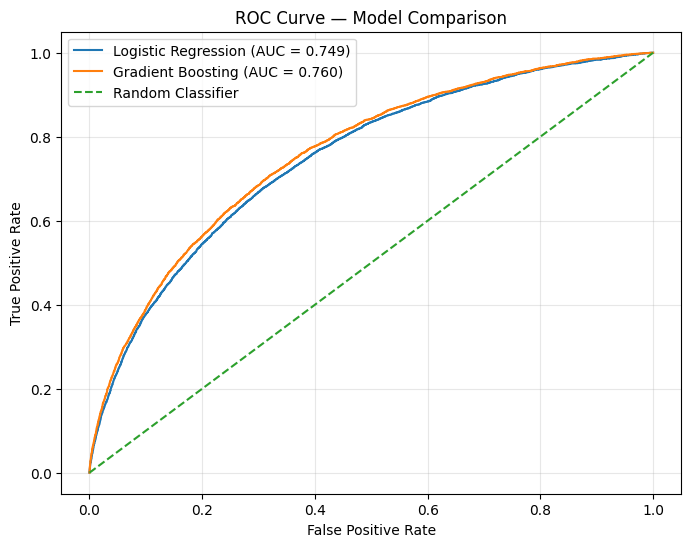

In [33]:
# ROC Curve
fpr_logistic, tpr_logistic, _ = roc_curve(y_engineered_test,
                                          y_prob_logistic_test)

fpr_gb, tpr_gb, _ = roc_curve(y_engineered_test,
                              y_prob_final_gb)

plt.figure(figsize=(8, 6))

plt.plot(fpr_logistic,
         tpr_logistic,
         label=f"Logistic Regression (AUC = {logistic_test_metrics['ROC-AUC']:.3f})")

plt.plot(fpr_gb,
         tpr_gb,
         label=f"Gradient Boosting (AUC = {final_gb_metrics['ROC-AUC']:.3f})")

plt.plot([0, 1],
         [0, 1],
         linestyle="--",
         label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Precision-Recall Analysis

The Precision-Recall curve provides a more informative view of classifier performance under the observed class imbalance.

Each point corresponds to a different probability threshold.

Moving toward higher recall generally requires accepting more false positives, reducing precision. The appropriate operating point therefore depends on the relative cost of missed defaults and unnecessary credit-risk interventions.

The curve is presented as a diagnostic of this trade-off. The final operating threshold will be selected separately using training/validation information rather than the test set.

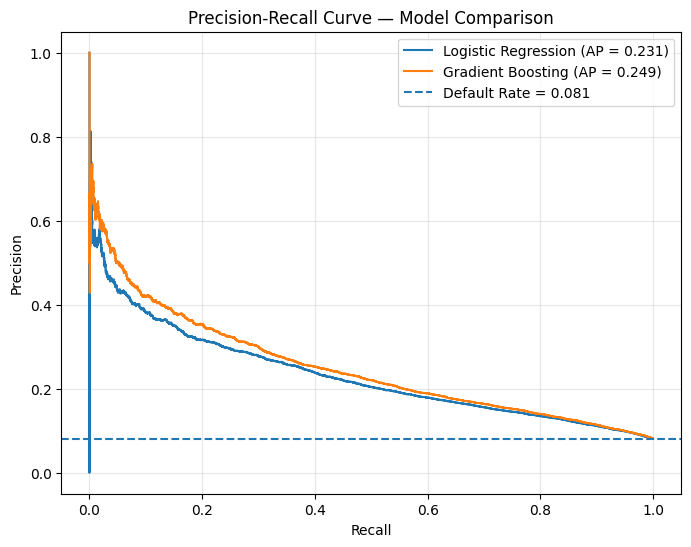

In [34]:
# Precision-Recall Curve
precision_logistic, recall_logistic, _ = precision_recall_curve(y_engineered_test,
                                                                y_prob_logistic_test)

precision_gb, recall_gb, _ = precision_recall_curve(y_engineered_test,
                                                    y_prob_final_gb)

plt.figure(figsize=(8, 6))

plt.plot(recall_logistic,
         precision_logistic,
         label=f"Logistic Regression (AP = {logistic_test_metrics['PR-AUC']:.3f})")

plt.plot(recall_gb,
         precision_gb,
         label=f"Gradient Boosting (AP = {final_gb_metrics['PR-AUC']:.3f})")

plt.axhline(y_engineered_test.mean(),
            linestyle="--",
            label=f"Default Rate = {y_engineered_test.mean():.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Probability Quality Assessment

Discriminatory performance evaluates whether the model ranks higher-risk applicants above lower-risk applicants. It does not establish whether the predicted probabilities correspond to observed default frequencies.

Because the model is intended for credit-risk applications, probability quality is evaluated separately.

The Brier score measures the mean squared difference between predicted probabilities and observed outcomes, with lower values indicating better probabilistic accuracy.

A calibration curve is also examined to compare predicted default probabilities with observed default frequencies.

These diagnostics are evaluated on the holdout test set for model assessment only. No model or threshold selection will be performed using these results.

In [35]:
# Probability quality — Brier score
brier_gb = brier_score_loss(y_engineered_test,
                            y_prob_final_gb)

brier_logistic = brier_score_loss(y_engineered_test,
                                  y_prob_logistic_test)

print(f"Gradient Boosting Brier Score: {brier_gb:.6f}")
print(f"Logistic Regression Brier Score: {brier_logistic:.6f}")

Gradient Boosting Brier Score: 0.067563
Logistic Regression Brier Score: 0.068383


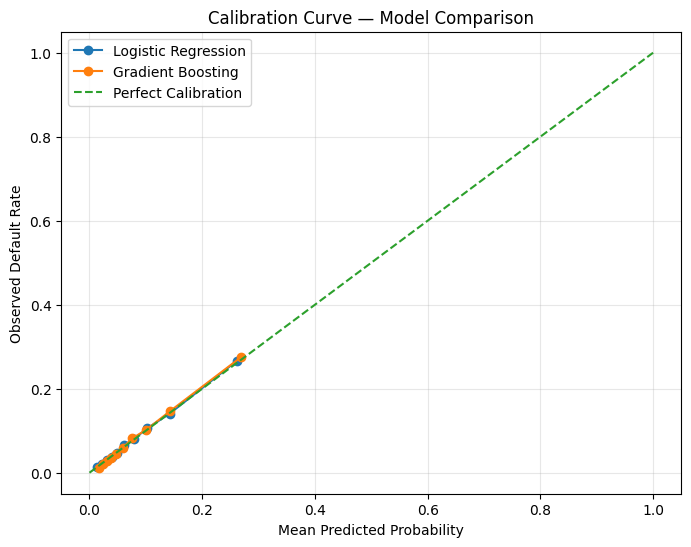

In [36]:
# Calibration curves
prob_true_gb, prob_pred_gb = calibration_curve(y_engineered_test,
                                               y_prob_final_gb,
                                               n_bins=10,
                                               strategy="quantile")

prob_true_logistic, prob_pred_logistic = calibration_curve(y_engineered_test,
                                                           y_prob_logistic_test,
                                                           n_bins=10,
                                                           strategy="quantile")

plt.figure(figsize=(8, 6))

plt.plot(prob_pred_logistic,
         prob_true_logistic,
         marker="o",
         label="Logistic Regression")

plt.plot(prob_pred_gb,
         prob_true_gb,
         marker="o",
         label="Gradient Boosting")

plt.plot([0, 1],
         [0, 1],
         linestyle="--",
         label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve — Model Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Credit Decision Threshold Analysis

The Gradient Boosting model produces a continuous probability of default rather than a binary credit decision.

A classification threshold determines which applicants are flagged as potential defaults. Changing this threshold changes the balance between:

- identifying more true defaults;
- incorrectly flagging lower-risk applicants.

Because the test set must remain an unbiased final evaluation sample, the operating threshold is selected using the validation sample created during model development.

No threshold is selected using test-set performance.

In [37]:
# Validation version of selected GB_5

gb5_validation_model = build_gb_pipeline(max_iter=200,
                                         learning_rate=0.05,
                                         max_leaf_nodes=31,
                                         min_samples_leaf=100,
                                         l2_regularization=2.0)

gb5_validation_model.fit(X_dev_train,
                         y_dev_train)

y_prob_gb_valid = gb5_validation_model.predict_proba(X_valid)[:, 1]

print("GB_5 validation model trained successfully.")
print(f"Validation observations: {len(y_valid):,}")
print(f"Mean predicted default probability: "
      f"{y_prob_gb_valid.mean():.4f}")
print(f"Observed default rate: "
      f"{y_valid.mean():.4f}")

GB_5 validation model trained successfully.
Validation observations: 49,202
Mean predicted default probability: 0.0814
Observed default rate: 0.0807


In [38]:
# Threshold performance analysis on the validation set

thresholds = np.arange(0.05, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_valid = (y_prob_gb_valid >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_valid,
                                      y_pred_valid).ravel()

    threshold_results.append({"Threshold": threshold,
                              "Precision": precision_score(y_valid, y_pred_valid, zero_division=0),
                              "Recall": recall_score(y_valid, y_pred_valid, zero_division=0),
                              "F1 Score": f1_score(y_valid, y_pred_valid, zero_division=0),
                              "False Positive Rate": fp / (fp + tn),
                              "Flagged Rate": (tp + fp) / len(y_valid),
                              "True Positives": tp,
                              "False Positives": fp,
                              "False Negatives": fn,
                              "True Negatives": tn})
    
threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.head()

,Threshold,Precision,Recall,F1 Score,False Positive Rate,Flagged Rate,True Positives,False Positives,False Negatives,True Negatives
0,0.05,0.129211,0.838117,0.223904,0.496020,0.523637,3329,22435,643,22795
1,0.06,0.141413,0.785247,0.239665,0.418682,0.448274,3119,18937,853,26293
2,0.07,0.154130,0.736657,0.254922,0.355030,0.385838,2926,16058,1046,29172
3,0.08,0.165419,0.684290,0.266431,0.303184,0.333950,2718,13713,1254,31517
4,0.09,0.174044,0.627644,0.272519,0.261574,0.291126,2493,11831,1479,33399


In [39]:
# F1-maximizing validation threshold
best_f1_row = (threshold_results_df.loc[threshold_results_df["F1 Score"].idxmax()])

print("Validation F1-optimal threshold:")
print(f"Threshold: {best_f1_row['Threshold']:.2f}")
print(f"Precision: {best_f1_row['Precision']:.4f}")
print(f"Recall: {best_f1_row['Recall']:.4f}")
print(f"F1 Score: {best_f1_row['F1 Score']:.4f}")
print(f"Flagged Rate: {best_f1_row['Flagged Rate']:.4f}")

Validation F1-optimal threshold:
Threshold: 0.16
Precision: 0.2428
Recall: 0.3867
F1 Score: 0.2983
Flagged Rate: 0.1286


In [40]:
# Threshold frontier
selected_thresholds = [0.05, 0.10, 0.15, 0.16, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_frontier = (threshold_results_df[threshold_results_df["Threshold"].apply(lambda x: any(np.isclose(x, t) for t in selected_thresholds))][["Threshold",
                                                                                                                                                   "Precision",
                                                                                                                                                   "Recall",
                                                                                                                                                   "F1 Score",
                                                                                                                                                   "False Positive Rate",
                                                                                                                                                   "Flagged Rate"]])

threshold_frontier

,Threshold,Precision,Recall,F1 Score,False Positive Rate,Flagged Rate
0,0.05,0.129211,0.838117,0.223904,0.496020,0.523637
5,0.10,0.184847,0.585347,0.280967,0.226686,0.255640
10,0.15,0.232307,0.412387,0.297197,0.119677,0.143307
11,0.16,0.242846,0.386707,0.298339,0.105881,0.128552
15,0.20,0.281456,0.290030,0.285679,0.065023,0.083188
20,0.25,0.328710,0.196878,0.246260,0.035308,0.048352
25,0.30,0.372325,0.131420,0.194269,0.019456,0.028495
30,0.35,0.416262,0.086354,0.143036,0.010635,0.016747
35,0.40,0.466083,0.053625,0.096184,0.005395,0.009288
40,0.45,0.530864,0.032477,0.061210,0.002520,0.004939


## Cost-Sensitive Credit Decision Analysis

Statistical threshold optimization does not necessarily correspond to the economically optimal credit decision rule.

A false negative represents a default that is not identified, while a false positive represents a non-default applicant who is unnecessarily flagged.

Because institution-specific monetary costs are unavailable, relative cost ratios are used rather than assigning arbitrary monetary values.

The analysis evaluates how the preferred operating threshold changes when the relative cost of a missed default increases.

In [41]:
# Cost-sensitive threshold analysis
cost_ratios = [1, 2, 5, 10]

cost_results = []

for fn_cost in cost_ratios:
    for _, row in threshold_results_df.iterrows():
        total_cost = (fn_cost * row["False Negatives"]
                      + row["False Positives"])

        cost_results.append({"FN_to_FP_Cost_Ratio": f"{fn_cost}:1",
                             "Threshold": row["Threshold"],
                             "Relative Cost": total_cost,
                             "Precision": row["Precision"],
                             "Recall": row["Recall"],
                             "F1 Score": row["F1 Score"],
                             "Flagged Rate": row["Flagged Rate"]})

cost_results_df = pd.DataFrame(cost_results)

print("Cost-sensitive analysis completed.")
print(f"Scenarios evaluated: {len(cost_ratios)}")

Cost-sensitive analysis completed.
Scenarios evaluated: 4


In [42]:
# Minimum-cost threshold under each cost ratio
cost_optimal_thresholds = (cost_results_df
                           .loc[cost_results_df.groupby("FN_to_FP_Cost_Ratio")["Relative Cost"].idxmin()]
                           .sort_values("FN_to_FP_Cost_Ratio")
                           .reset_index(drop=True))

cost_optimal_thresholds

,FN_to_FP_Cost_Ratio,Threshold,Relative Cost,Precision,Recall,F1 Score,Flagged Rate
0,10:1,0.08,26253.0,0.165419,0.684290,0.266431,0.333950
1,1:1,0.46,3946.0,0.563725,0.028953,0.055077,0.004146
2,2:1,0.38,7729.0,0.455631,0.067221,0.117157,0.011910
3,5:1,0.17,16961.0,0.252168,0.358761,0.296165,0.114853


In [43]:
# Compact decision-policy summary
decision_policy_summary = cost_optimal_thresholds[["FN_to_FP_Cost_Ratio",
                                                   "Threshold",
                                                   "Precision",
                                                   "Recall",
                                                   "F1 Score",
                                                   "Flagged Rate",
                                                   "Relative Cost"]].copy()

decision_policy_summary["Cost_Ratio_Numeric"] = (decision_policy_summary["FN_to_FP_Cost_Ratio"]
                                                 .str.split(":")
                                                 .str[0]
                                                 .astype(int))

decision_policy_summary = (decision_policy_summary
                           .sort_values("Cost_Ratio_Numeric")
                           .drop(columns="Cost_Ratio_Numeric")
                           .reset_index(drop=True))
decision_policy_summary

,FN_to_FP_Cost_Ratio,Threshold,Precision,Recall,F1 Score,Flagged Rate,Relative Cost
0,1:1,0.46,0.563725,0.028953,0.055077,0.004146,3946.0
1,2:1,0.38,0.455631,0.067221,0.117157,0.011910,7729.0
2,5:1,0.17,0.252168,0.358761,0.296165,0.114853,16961.0
3,10:1,0.08,0.165419,0.684290,0.266431,0.333950,26253.0


## Final Test-Set Decision Analysis

The selected Gradient Boosting model and validation-derived operating thresholds are evaluated on the held-out test set.

The test set is not used to optimize the model or select an operating threshold in the final workflow. It is used to estimate out-of-sample performance under decision rules determined from the validation sample.

The analysis evaluates the statistical F1-optimal threshold identified on the validation sample together with cost-sensitive thresholds obtained under alternative false-negative-to-false-positive cost assumptions.

In [44]:
# Final test-set evaluation at validation-derived thresholds

evaluation_thresholds = {"F1-optimal (validation)": float(best_f1_row["Threshold"]),
                         "Cost ratio 1:1": float(cost_optimal_thresholds.loc[cost_optimal_thresholds["FN_to_FP_Cost_Ratio"] == "1:1","Threshold"].iloc[0]),
                         "Cost ratio 2:1": float(cost_optimal_thresholds.loc[cost_optimal_thresholds["FN_to_FP_Cost_Ratio"] == "2:1","Threshold"].iloc[0]),
                         "Cost ratio 5:1": float(cost_optimal_thresholds.loc[cost_optimal_thresholds["FN_to_FP_Cost_Ratio"] == "5:1","Threshold"].iloc[0]),
                         "Cost ratio 10:1": float(cost_optimal_thresholds.loc[cost_optimal_thresholds["FN_to_FP_Cost_Ratio"] == "10:1","Threshold"].iloc[0])}

final_threshold_results = []

for policy_name, threshold in evaluation_thresholds.items():

    y_pred_test = (y_prob_final_gb >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_engineered_test,
                                      y_pred_test).ravel()

    final_threshold_results.append({"Policy": policy_name,
                                    "Threshold": threshold,
                                    "Precision": precision_score(y_engineered_test, y_pred_test, zero_division=0),
                                    "Recall": recall_score(y_engineered_test, y_pred_test, zero_division=0),
                                    "F1 Score": f1_score(y_engineered_test, y_pred_test, zero_division=0),
                                    "False Positive Rate": fp / (fp + tn),
                                    "Flagged Rate": (tp + fp) / len(y_engineered_test),
                                    "True Positives": tp,
                                    "False Positives": fp,
                                    "False Negatives": fn,
                                    "True Negatives": tn})

final_threshold_results_df = pd.DataFrame(final_threshold_results)

final_threshold_results_df

,Policy,Threshold,Precision,Recall,F1 Score,False Positive Rate,Flagged Rate,True Positives,False Positives,False Negatives,True Negatives
0,F1-optimal (validation),0.16,0.255727,0.386707,0.307865,0.098836,0.122075,1920,5588,3045,50950
1,Cost ratio 1:1,0.46,0.576613,0.028802,0.054863,0.001857,0.004032,143,105,4822,56433
2,Cost ratio 2:1,0.38,0.467422,0.066465,0.116382,0.006650,0.011479,330,376,4635,56162
3,Cost ratio 5:1,0.17,0.267305,0.360121,0.306847,0.086685,0.108759,1788,4901,3177,51637
4,Cost ratio 10:1,0.08,0.167698,0.681974,0.269200,0.297234,0.328293,3386,16805,1579,39733


## Decision Analysis Findings

The validation-derived decision thresholds are evaluated on the held-out test set.

The F1-optimal validation threshold identifies approximately 38.7% of observed defaults on the test set while flagging approximately 12.2% of applicants, with precision of approximately 25.6%.

The cost-sensitive analysis demonstrates that the preferred operating point depends materially on the relative cost of false negatives and false positives.

Under a 1:1 cost ratio, the model operates as a highly selective screening mechanism, whereas a 10:1 ratio produces substantially higher recall at the expense of a much larger flagged population and lower precision.

Therefore, threshold selection is treated as a credit-policy decision rather than an intrinsic property of the predictive model.

The predictive model and the credit decision rule are consequently considered separate components:

1. The Gradient Boosting model estimates relative default risk.
2. The operating threshold converts predicted risk into a decision according to the institution's objectives and risk appetite.

## Global Model Explainability

Global explainability is used to identify the predictors that contribute most to the Gradient Boosting model's out-of-sample discrimination.

Permutation importance is used because the selected Gradient Boosting implementation does not provide a directly interpretable coefficient structure comparable to Logistic Regression.

Each predictor is permuted while the remaining predictors are held constant. The resulting deterioration in PR-AUC provides an estimate of the predictor's contribution to model discrimination.

PR-AUC is used as the importance metric because it is the primary model-selection metric for this imbalanced credit-default problem.

Permutation importance should be interpreted as predictive importance rather than causal importance. Correlated predictors may share information, causing the measured importance of individual variables to be distributed across related features.

In [45]:
# Global permutation importance

# Use a fixed validation sample for computational efficiency.
explainability_sample_size = min(20000, len(X_valid))

X_explain = X_valid.sample(n=explainability_sample_size,
                              random_state=RANDOM_STATE)

y_explain = y_valid.loc[X_explain.index]

print("Explainability sample:", X_explain.shape)
print("Default rate:", y_explain.mean())

Explainability sample: (20000, 109)
Default rate: 0.0805


In [46]:
# Permutation importance using PR-AUC
permutation_result = permutation_importance(final_gb_pipeline,
                                            X_explain,
                                            y_explain,
                                            scoring="average_precision",
                                            n_repeats=1,
                                            random_state=RANDOM_STATE,
                                            n_jobs=-1)

print("Permutation importance calculated successfully.")

Permutation importance calculated successfully.


In [47]:
# Feature importance table
feature_importance_df = pd.DataFrame({"Feature": X_explain.columns,
                                      "Importance_Mean": permutation_result.importances_mean,
                                      "Importance_SD": permutation_result.importances_std})

feature_importance_df = (feature_importance_df
                         .sort_values("Importance_Mean", ascending=False)
                         .reset_index(drop=True))

feature_importance_df.head(20)

,Feature,Importance_Mean,Importance_SD
0,EXT_SOURCE_3,0.080461,0.0
1,EXT_SOURCE_2,0.065343,0.0
2,EXT_SOURCE_1,0.038165,0.0
3,CODE_GENDER,0.013945,0.0
4,LOAN_GOODS_RATIO,0.013942,0.0
5,AMT_ANNUITY,0.012756,0.0
6,AMT_GOODS_PRICE,0.010640,0.0
7,DAYS_BIRTH,0.010543,0.0
8,EMPLOYMENT_YEARS,0.009533,0.0
9,AMT_CREDIT,0.007288,0.0


In [48]:
# Importance of engineered features
engineered_importance = feature_importance_df[feature_importance_df["Feature"].isin(engineered_features_names)].copy()

engineered_importance

,Feature,Importance_Mean,Importance_SD
4,LOAN_GOODS_RATIO,0.013942,0.0
8,EMPLOYMENT_YEARS,0.009533,0.0
12,CREDIT_INCOME_RATIO,0.005076,0.0
13,AGE_YEARS,0.004977,0.0
20,ANNUITY_INCOME_RATIO,0.002919,0.0
95,EMPLOYMENT_ANOMALY,0.000000,0.0


## Robust Global Feature Importance

The initial permutation-importance analysis provides a first-pass ranking of predictors.

To assess the stability of the importance estimates, the analysis is repeated across five random permutations using the same validation-based explainability sample.

Mean importance represents the average deterioration in PR-AUC following permutation, while the standard deviation indicates variability across permutation repetitions.

Importance is interpreted as predictive contribution rather than causal effect.

In [49]:
# Robust permutation importance
permutation_result_robust = permutation_importance(final_gb_pipeline,
                                                   X_explain,
                                                   y_explain,
                                                   scoring="average_precision",
                                                   n_repeats=5,
                                                   random_state=RANDOM_STATE,
                                                   n_jobs=-1)

print("Robust permutation importance calculated successfully.")

Robust permutation importance calculated successfully.


In [50]:
# Robust feature-importance table
feature_importance_robust_df = pd.DataFrame({"Feature": X_explain.columns,
                                             "Importance_Mean": permutation_result_robust.importances_mean,
                                             "Importance_SD": permutation_result_robust.importances_std})

feature_importance_robust_df = (feature_importance_robust_df
                                .sort_values("Importance_Mean", ascending=False)
                                .reset_index(drop=True))

feature_importance_robust_df.head(20)

,Feature,Importance_Mean,Importance_SD
0,EXT_SOURCE_3,0.082291,0.002021
1,EXT_SOURCE_2,0.069462,0.004283
2,EXT_SOURCE_1,0.033138,0.003178
3,LOAN_GOODS_RATIO,0.016387,0.002652
4,AMT_GOODS_PRICE,0.013013,0.002761
5,AMT_ANNUITY,0.012786,0.001367
6,CODE_GENDER,0.012785,0.002691
7,DAYS_BIRTH,0.010501,0.000589
8,EMPLOYMENT_YEARS,0.007851,0.001472
9,NAME_FAMILY_STATUS,0.005792,0.001675


In [51]:
# Engineered feature importance
engineered_features_names = ["CREDIT_INCOME_RATIO",
                             "ANNUITY_INCOME_RATIO",
                             "LOAN_GOODS_RATIO",
                             "AGE_YEARS",
                             "EMPLOYMENT_YEARS",
                             "EMPLOYMENT_ANOMALY"]

engineered_importance = (feature_importance_robust_df[feature_importance_robust_df["Feature"].isin(engineered_features_names)]
                         .sort_values("Importance_Mean", ascending=False)
                         .reset_index(drop=True))

engineered_importance

,Feature,Importance_Mean,Importance_SD
0,LOAN_GOODS_RATIO,0.016387,0.002652
1,EMPLOYMENT_YEARS,0.007851,0.001472
2,AGE_YEARS,0.004147,0.001060
3,CREDIT_INCOME_RATIO,0.003652,0.001051
4,ANNUITY_INCOME_RATIO,0.002372,0.001004
5,EMPLOYMENT_ANOMALY,0.000000,0.000000


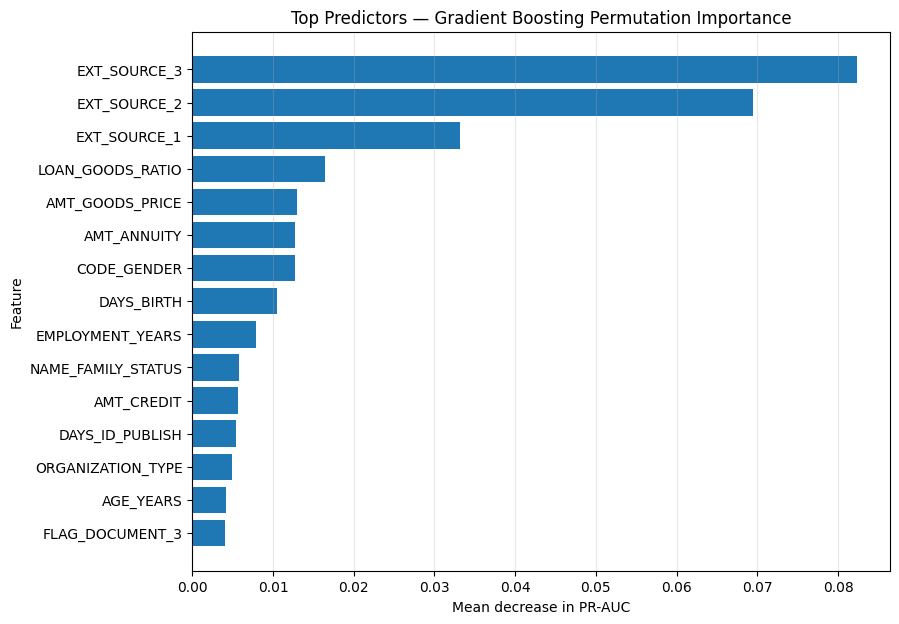

In [52]:
# Top 15 global feature importance
top_features = (feature_importance_robust_df
                .head(15)
                .sort_values("Importance_Mean", ascending=True))

plt.figure(figsize=(9, 7))

plt.barh(top_features["Feature"],
         top_features["Importance_Mean"])

plt.xlabel("Mean decrease in PR-AUC")
plt.ylabel("Feature")
plt.title("Top Predictors — Gradient Boosting Permutation Importance")

plt.grid(axis="x", alpha=0.3)

plt.show()

## Directional Risk Relationships

Global permutation importance identifies predictors that contribute to model discrimination but does not describe the direction of their relationship with predicted default risk.

Partial dependence analysis is therefore used for selected continuous predictors to examine how the model's average predicted default probability changes across the observed feature range.

The analysis focuses on variables with meaningful global permutation importance, including external credit-quality measures and selected engineered credit-burden variables.

Partial dependence describes the behaviour of the fitted predictive model and should not be interpreted as causal evidence. Relationships may also be affected by correlation between predictors and extrapolation in regions with limited observations.

d:\Softwares\Python\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


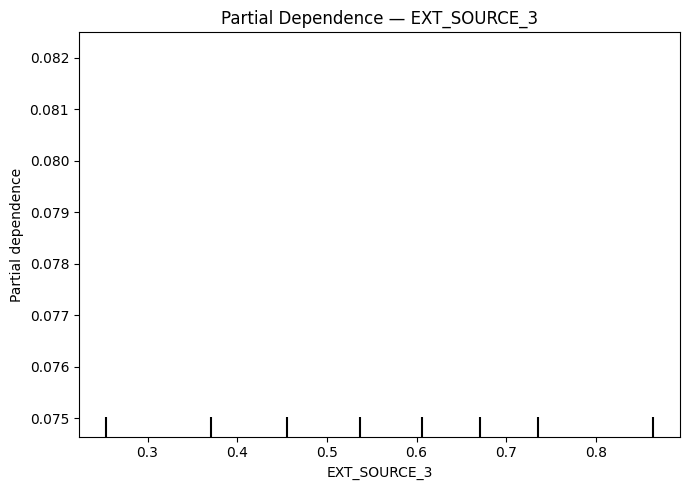

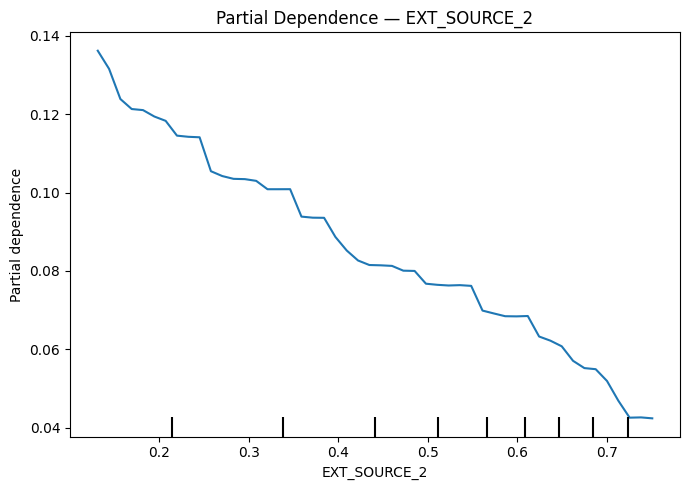

d:\Softwares\Python\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


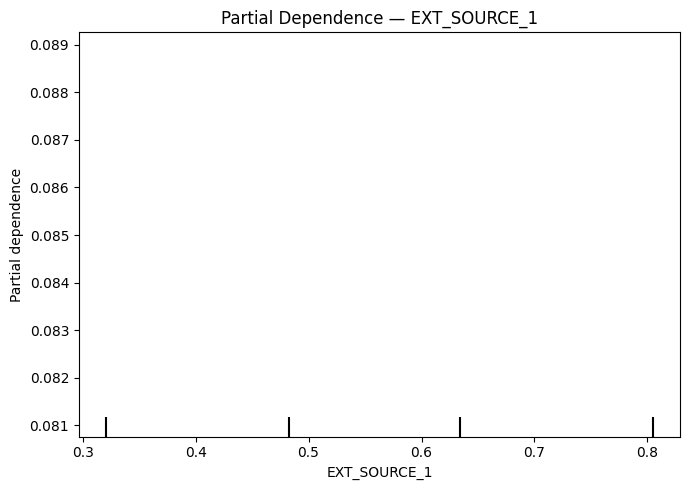

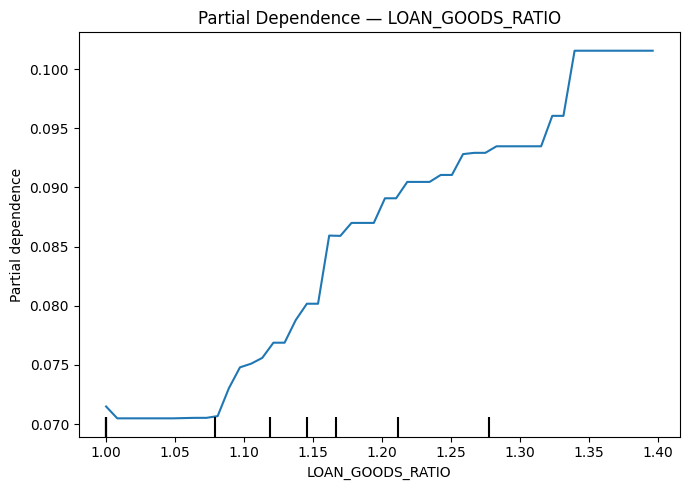

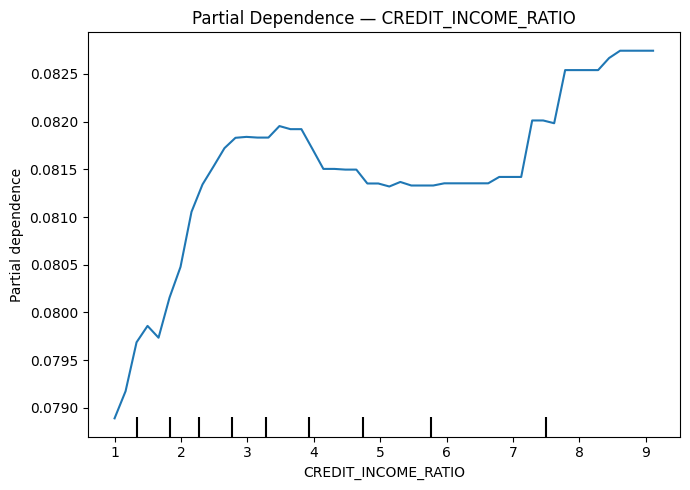

d:\Softwares\Python\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


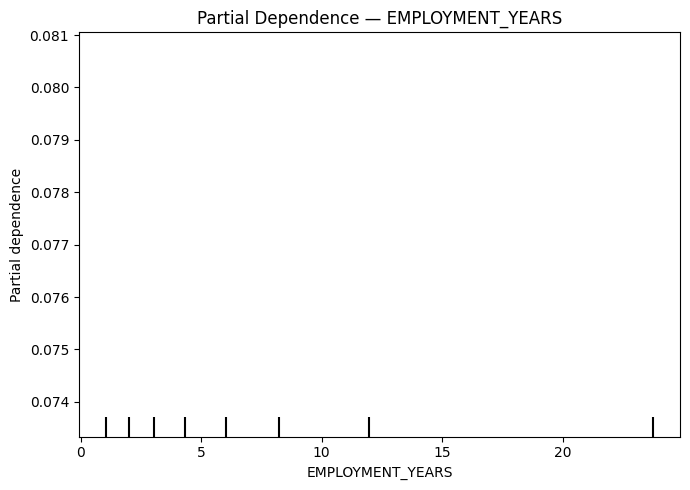

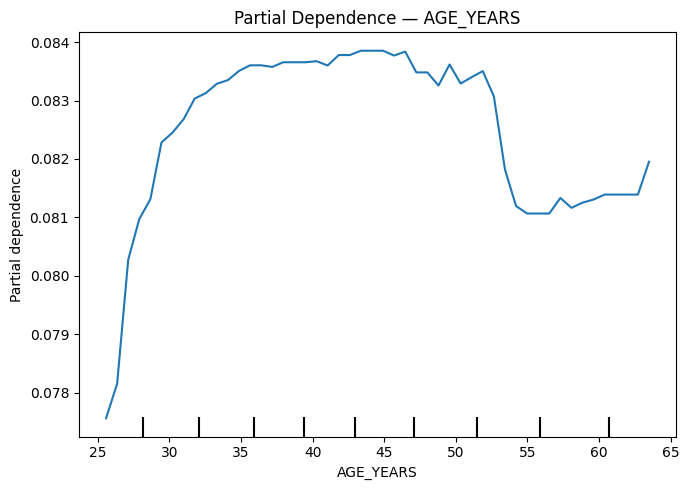

In [53]:
# Partial Dependence — selected continuous risk drivers
pd_features = ["EXT_SOURCE_3",
               "EXT_SOURCE_2",
               "EXT_SOURCE_1",
               "LOAN_GOODS_RATIO",
               "CREDIT_INCOME_RATIO",
               "EMPLOYMENT_YEARS",
               "AGE_YEARS"]

for feature in pd_features:
    fig, ax = plt.subplots(figsize=(7, 5))

    PartialDependenceDisplay.from_estimator(final_gb_pipeline,
                                            X_explain,
                                            features=[feature],
                                            kind="average",
                                            grid_resolution=50,
                                            ax=ax)
    
    ax.set_title(f"Partial Dependence — {feature}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [54]:
# Final global risk-driver table
risk_driver_table = (feature_importance_robust_df
                     .head(15)[["Feature",
                                "Importance_Mean",
                                "Importance_SD"]].copy())

risk_driver_table

,Feature,Importance_Mean,Importance_SD
0,EXT_SOURCE_3,0.082291,0.002021
1,EXT_SOURCE_2,0.069462,0.004283
2,EXT_SOURCE_1,0.033138,0.003178
3,LOAN_GOODS_RATIO,0.016387,0.002652
4,AMT_GOODS_PRICE,0.013013,0.002761
5,AMT_ANNUITY,0.012786,0.001367
6,CODE_GENDER,0.012785,0.002691
7,DAYS_BIRTH,0.010501,0.000589
8,EMPLOYMENT_YEARS,0.007851,0.001472
9,NAME_FAMILY_STATUS,0.005792,0.001675


### Interpretation of External Credit-Quality Variables

The external credit-quality variables exhibit high permutation importance, but their partial-dependence relationships are not uniformly strong.

In particular, EXT_SOURCE_2 displays a clear inverse relationship with model-estimated default probability, whereas EXT_SOURCE_1 and EXT_SOURCE_3 exhibit comparatively flat partial-dependence curves.

This difference should not be interpreted as evidence that EXT_SOURCE_1 or EXT_SOURCE_3 are unimportant. Correlation and information overlap among predictors can affect marginal interpretation. Consequently, permutation importance is used as the primary global importance measure, while partial dependence is treated as a complementary directional diagnostic.

## Out-of-Sample Risk Segmentation

The selected Gradient Boosting model produces a continuous predicted probability of default for each applicant.

To assess whether the model meaningfully separates borrowers by risk, applicants are grouped into ten validation-derived predicted-risk bands.

Ten risk-band boundaries are derived from validation-sample predicted-risk quantiles and subsequently applied unchanged to the test sample. Consequently, the resulting test groups are not required to contain exactly 10% of test observations.

Within each test-set segment, the following quantities are examined:

- number of applicants;
- average predicted probability of default;
- observed default rate;
- default lift relative to the overall test-set default rate;
- proportion of all observed defaults captured by the segment.

This provides an intuitive portfolio-level assessment of the model's ranking ability.

In [55]:
# Validation-based risk segmentation boundaries
risk_quantiles = np.quantile(y_prob_gb_valid,
                             np.arange(0, 1.01, 0.10))

# Ensure boundaries are strictly increasing
risk_quantiles = np.unique(risk_quantiles)

print("Number of unique risk boundaries:", len(risk_quantiles))
print("Risk boundaries:")
print(risk_quantiles)

Number of unique risk boundaries: 11
Risk boundaries:
[0.00662403 0.01984535 0.02628022 0.03329297 0.04190016 0.05285628
 0.0676556  0.08787496 0.12038405 0.18361658 0.73030104]


In [56]:
# Apply validation-derived risk bands to test predictions
risk_labels = ["Risk Decile 1",
               "Risk Decile 2",
               "Risk Decile 3",
               "Risk Decile 4",
               "Risk Decile 5",
               "Risk Decile 6",
               "Risk Decile 7",
               "Risk Decile 8",
               "Risk Decile 9",
               "Risk Decile 10"]

# Use percentile rank as a robust way to assign test observations according to the validation-derived distribution.

test_risk_percentile = np.searchsorted(risk_quantiles,
                                       y_prob_final_gb,
                                       side="right") - 1

test_risk_percentile = np.clip(test_risk_percentile, 0, 9)

test_risk_decile = pd.Categorical([risk_labels[i] for i in test_risk_percentile],
                                  categories=risk_labels,
                                  ordered=True)

risk_segmentation_test = pd.DataFrame({"Predicted_PD": y_prob_final_gb,
                                       "Actual_Default": y_engineered_test.to_numpy(),
                                       "Risk_Decile": test_risk_decile})

risk_segmentation_test.head()

,Predicted_PD,Actual_Default,Risk_Decile
0,0.049493,0,Risk Decile 5
1,0.040657,0,Risk Decile 4
2,0.291817,0,Risk Decile 10
3,0.062752,0,Risk Decile 6
4,0.081866,0,Risk Decile 7


In [57]:
# Risk segmentation performance
overall_test_default_rate = y_engineered_test.mean()

risk_segment_summary = (risk_segmentation_test
                        .groupby("Risk_Decile", observed=False)
                        .agg(Applicants=("Actual_Default", "size"),
                             Mean_Predicted_PD=("Predicted_PD", "mean"),
                             Observed_Default_Rate=("Actual_Default", "mean"),
                             Defaults=("Actual_Default", "sum"))
                        .reset_index())

risk_segment_summary["Portfolio_Share"] = (risk_segment_summary["Applicants"]
                                           / len(risk_segmentation_test))

risk_segment_summary["Default_Lift"] = (risk_segment_summary["Observed_Default_Rate"]
                                        / overall_test_default_rate)

risk_segment_summary["Default_Capture"] = (risk_segment_summary["Defaults"]
                                           / risk_segment_summary["Defaults"].sum())

risk_segment_summary

,Risk_Decile,Applicants,Mean_Predicted_PD,Observed_Default_Rate,Defaults,Portfolio_Share,Default_Lift,Default_Capture
0,Risk Decile 1,5625,0.015901,0.012267,69,0.091459,0.151951,0.013897
1,Risk Decile 2,6007,0.023077,0.019810,119,0.097670,0.245395,0.023968
2,Risk Decile 3,6173,0.029721,0.027215,168,0.100369,0.337124,0.033837
3,Risk Decile 4,6497,0.037482,0.033246,216,0.105637,0.411830,0.043505
4,Risk Decile 5,6542,0.047178,0.046010,301,0.106369,0.569945,0.060624
5,Risk Decile 6,6516,0.059806,0.060160,392,0.105946,0.745216,0.078953
6,Risk Decile 7,6091,0.077106,0.083894,511,0.099036,1.039224,0.102920
7,Risk Decile 8,6124,0.102679,0.103690,635,0.099572,1.284445,0.127895
8,Risk Decile 9,6186,0.147568,0.151148,935,0.100580,1.872314,0.188318
9,Risk Decile 10,5742,0.275645,0.281958,1619,0.093361,3.492695,0.326083


In [58]:
# Three-band analytical risk segmentation
risk_band_mapping = {"Risk Decile 1": "Low Risk",
                     "Risk Decile 2": "Low Risk",
                     "Risk Decile 3": "Low Risk",
                     "Risk Decile 4": "Low Risk",
                     "Risk Decile 5": "Low Risk",
                     "Risk Decile 6": "Medium Risk",
                     "Risk Decile 7": "Medium Risk",
                     "Risk Decile 8": "Medium Risk",
                     "Risk Decile 9": "High Risk",
                     "Risk Decile 10": "High Risk"}

risk_segmentation_test["Risk_Band"] = (risk_segmentation_test["Risk_Decile"]
                                       .map(risk_band_mapping))

risk_band_summary = (risk_segmentation_test
                    .groupby("Risk_Band", observed=False)
                    .agg(Applicants=("Actual_Default", "size"),
                         Mean_Predicted_PD=("Predicted_PD", "mean"),
                         Observed_Default_Rate=("Actual_Default", "mean"),
                         Defaults=("Actual_Default", "sum"))
                    .reset_index())
risk_band_order = ["Low Risk",
                   "Medium Risk",
                   "High Risk"]

risk_band_summary["Risk_Band"] = pd.Categorical(risk_band_summary["Risk_Band"],
                                                categories=risk_band_order,
                                                ordered=True)

risk_band_summary = (risk_band_summary
                     .sort_values("Risk_Band")
                     .reset_index(drop=True))


risk_band_summary["Portfolio_Share"] = (risk_band_summary["Applicants"]
                                        / risk_band_summary["Applicants"].sum())

risk_band_summary["Default_Lift"] = (risk_band_summary["Observed_Default_Rate"]
                                     / y_engineered_test.mean())

risk_band_summary["Default_Capture"] = (risk_band_summary["Defaults"]
                                        / risk_band_summary["Defaults"].sum())

risk_band_summary

,Risk_Band,Applicants,Mean_Predicted_PD,Observed_Default_Rate,Defaults,Portfolio_Share,Default_Lift,Default_Capture
0,Low Risk,30844,0.031244,0.028304,873,0.501504,0.350607,0.175831
1,Medium Risk,18731,0.079449,0.082110,1538,0.304554,1.017121,0.309768
2,High Risk,11928,0.209223,0.214118,2554,0.193942,2.652347,0.514401


### Risk Segmentation Findings

The model produces substantial separation in observed default rates across the analytical risk bands.

The Low Risk segment represents approximately 50.2% of the test population and has an observed default rate of 2.83%, substantially below the portfolio-average default rate.

The Medium Risk segment represents approximately 30.5% of applicants and has an observed default rate of 8.21%, broadly consistent with the portfolio average.

The High Risk segment represents only approximately 19.4% of applicants but contains 51.4% of all observed defaults and has an observed default rate of 21.41%, corresponding to approximately 2.65 times the portfolio-average default rate.

These results indicate that the Gradient Boosting model provides meaningful portfolio-level risk stratification. The three-band classification is an analytical segmentation for model evaluation and should not be interpreted as a regulatory or institution-specific credit-grade framework.

## Kolmogorov–Smirnov (KS) Analysis

The Kolmogorov–Smirnov statistic is used as an additional ranking diagnostic commonly associated with credit-scoring applications.

Applicants are ordered by predicted probability of default, and the cumulative proportion of defaults and non-defaults is compared across the ordered population.

The maximum separation between the two cumulative distributions provides the KS statistic.

The test set is used only for final out-of-sample assessment; no model or threshold selection is performed using the KS result.

In [59]:
# KS curve across ranked population
ks_df = pd.DataFrame({"Predicted_PD": y_prob_final_gb,
                      "Actual_Default": y_engineered_test.to_numpy()})

ks_df = (ks_df
         .sort_values("Predicted_PD", ascending=False)
         .reset_index(drop=True))

ks_df["Cumulative_Defaults"] = (ks_df["Actual_Default"].cumsum()
                                / ks_df["Actual_Default"].sum())

ks_df["Cumulative_NonDefaults"] = ((1 - ks_df["Actual_Default"]).cumsum()
                                   / (1 - ks_df["Actual_Default"]).sum())

ks_df["Population_Percentile"] = (np.arange(1, len(ks_df) + 1)
                                  / len(ks_df))

ks_df["KS"] = (ks_df["Cumulative_Defaults"] - ks_df["Cumulative_NonDefaults"])

ks_max_index = ks_df["KS"].abs().idxmax()

ks_population = ks_df.loc[ks_max_index,
                          "Population_Percentile"]

ks_max_value = ks_df.loc[ks_max_index,
                         "KS"]

print(f"KS Statistic: {ks_max_value:.4f}")
print(f"Population at maximum separation: "
      f"{ks_population:.2%}")

KS Statistic: 0.3880
Population at maximum separation: 35.15%


## KS Population Separation

The KS curve is presented across the ranked applicant population rather than as a function of the model threshold.

Applicants are ordered from highest to lowest predicted default probability. The cumulative share of observed defaults and non-defaults is then compared across the population.

The maximum vertical separation corresponds to the KS statistic.

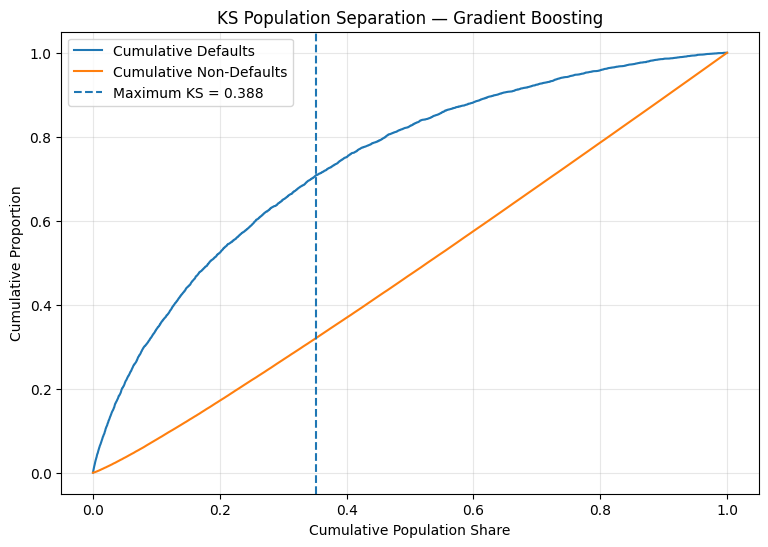

In [60]:
# KS population-separation plot
plt.figure(figsize=(9, 6))

plt.plot(ks_df["Population_Percentile"],
         ks_df["Cumulative_Defaults"],
         label="Cumulative Defaults")

plt.plot(ks_df["Population_Percentile"],
         ks_df["Cumulative_NonDefaults"],
         label="Cumulative Non-Defaults")

plt.axvline(ks_population,
            linestyle="--",
            label=f"Maximum KS = {ks_max_value:.3f}")

plt.xlabel("Cumulative Population Share")
plt.ylabel("Cumulative Proportion")
plt.title("KS Population Separation — Gradient Boosting")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### KS Findings

The final Gradient Boosting model achieves a KS statistic of 0.3880 on the held-out test set.

The maximum separation between the cumulative distributions of defaults and non-defaults occurs at approximately 35.15% of the ranked population.

The KS result provides additional evidence that the model separates higher-risk and lower-risk applicants effectively. The population location associated with maximum KS is treated solely as a discrimination diagnostic and is not used as the operational credit-decision threshold, since the latter must be determined using validation data and institution-specific decision costs.

## Model Governance, Limitations and Appropriate Use

The final Gradient Boosting model provides useful discriminatory power and portfolio-level risk stratification, but its outputs should be interpreted within the limitations of the development dataset and modeling framework.

### Data and population limitations

The model is developed from a historical application dataset. Its performance reflects the characteristics of the observed population and historical lending process and may not automatically generalize to materially different applicant populations, products, economic environments or underwriting policies.

### Target and selection considerations

The observed default outcome reflects historical application and lending processes. Applicants who were not observed under comparable lending conditions may introduce selection effects that are not fully captured by the model.

### Feature limitations

Several predictors, particularly the external credit-quality variables, contain substantial predictive information. Their precise construction and underlying data-generating processes are external to this modeling exercise.

### Predictive versus causal interpretation

Feature importance and partial-dependence results describe relationships learned by the predictive model. They do not establish that changing an individual characteristic would causally change default probability.

### Threshold and policy limitations

The predicted probability of default and the classification threshold represent separate components of the credit decision framework. The appropriate operating threshold depends on institution-specific objectives, risk appetite, operational capacity and the relative costs of false-positive and false-negative decisions.

### Fairness and governance considerations

Variables with demographic or potentially sensitive characteristics should receive additional governance review before deployment. Predictive usefulness alone is not sufficient justification for using a feature in an operational credit decision process.

### Monitoring requirements

A production implementation would require ongoing monitoring of discrimination, calibration, population stability, feature drift, missingness, outcome rates and segment-level performance.

### Deployment limitation

The model should therefore be regarded as a research and analytical credit-risk model rather than a production-ready lending decision system. Production deployment would require independent validation, governance approval, documented data lineage, monitoring procedures and institution-specific policy design.

## Final Model Card

| Component | Final Specification |
|---|---|
| Problem | Binary credit-default prediction |
| Model | Histogram-based Gradient Boosting |
| Final model selection | Validation-based model comparison and hyperparameter optimization |
| Training observations | 246,008 |
| Test observations | 61,503 |
| Test default rate | 8.07% |
| Number of input features | 109 |
| ROC-AUC | 0.7603 |
| PR-AUC | 0.2495 |
| Brier Score | 0.067563 |
| KS Statistic | 0.3880 |
| F1-optimal validation threshold | 0.16 |
| Test precision at 0.16 | 25.57% |
| Test recall at 0.16 | 38.67% |
| Test F1 at 0.16 | 30.79% |
| Test flagged rate at 0.16 | 12.21% |
| Highest-risk risk-band default rate | 28.20% |
| Highest-risk risk-band lift | 3.49× |
| High-risk band population share | 19.39% |
| High-risk band default capture | 51.44% |

### Primary interpretation

The final Gradient Boosting model demonstrates meaningful discrimination between defaulting and non-defaulting applicants and provides useful portfolio-level risk stratification.

The model's continuous probability output should be separated conceptually from the credit decision threshold. Threshold selection is a policy decision that depends on the institution's loss function and risk appetite rather than solely on predictive performance.

The reported threshold metrics are based on thresholds derived from the validation sample and subsequently evaluated on the held-out test set.

## Final Analytical Conclusions

1. The Gradient Boosting model was selected as the final predictive model after validation-based comparison with Logistic Regression and Random Forest, followed by validation-based hyperparameter optimization.

2. The final model achieved a test ROC-AUC of 0.7603 and PR-AUC of 0.2495, demonstrating meaningful discrimination in an imbalanced default-prediction setting.

3. The final model achieved a Brier score of 0.067563, indicating reasonably close agreement between predicted probabilities and observed default outcomes at the portfolio level.

4. Threshold analysis demonstrated a substantial precision-recall trade-off. The validation F1-optimal threshold was 0.16, which achieved 38.67% recall and 25.57% precision on the held-out test set.

5. Cost-sensitive analysis demonstrated that the preferred operating threshold depends materially on the relative cost assigned to missed defaults versus unnecessary risk flags.

6. Global permutation importance identified the three external credit-quality variables as the dominant predictors, while several engineered variables—particularly LOAN_GOODS_RATIO and EMPLOYMENT_YEARS—also contributed meaningful predictive information.

7. Partial-dependence analysis showed an inverse marginal relationship between EXT_SOURCE_2 and predicted default probability and a positive nonlinear marginal relationship between LOAN_GOODS_RATIO and predicted default probability. These relationships describe model behaviour rather than causal effects.

8. Risk segmentation demonstrated meaningful portfolio separation. The highest-risk validation-derived risk band had a 28.20% observed default rate and 3.49× the portfolio-average default rate.

9. The analytical High Risk band represented 19.39% of applicants while containing 51.44% of observed defaults, illustrating the model's potential usefulness for risk-based portfolio screening.

10. The KS statistic of 0.3880 provides additional evidence of meaningful separation between defaulting and non-defaulting applicants.

11. Overall, the project demonstrates an end-to-end credit-risk modeling workflow covering data preparation, feature engineering, model development, validation, calibration, threshold optimization, cost-sensitive decision analysis, explainability and portfolio risk segmentation.

12. The model should be regarded as a research and analytical credit-risk model rather than a production-ready lending decision system. Production implementation would require independent validation, fairness and regulatory review, documented data lineage, monitoring for drift and calibration deterioration, and institution-specific policy and loss assumptions.